## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import plotting

## Step 1. Load the Data

In [2]:
tsla = pd.read_csv(
    "../data/processed/TSLA_cleaned.csv",
    index_col=0,
    parse_dates=True
)

bnd = pd.read_csv(
    "../data/processed/BND_cleaned.csv",
    header=[0,1],
    index_col=0,
    parse_dates=True
)

spy = pd.read_csv(
    "../data/processed/SPY_cleaned.csv",
    header=[0,1],
    index_col=0,
    parse_dates=True
)

## Step 2. Create Daily Returns

In [3]:
returns = pd.DataFrame()

returns["TSLA"] = tsla["Adj Close"].pct_change()

returns["BND"] = bnd["Adj Close"].pct_change()

returns["SPY"] = spy["Adj Close"].pct_change()

returns = returns.dropna()

## Step 3. Expected Returns

### Tesla

In [4]:
forecast = pd.read_csv(
    "../data/processed/TSLA_future_forecast.csv",
    index_col=0,
    parse_dates=True
)
current_price = tsla["Adj Close"].iloc[-1]
future_price = forecast["Forecast"].iloc[-1]
expected_tsla = (future_price - current_price) / current_price

### BND and SPY

In [5]:
expected_bnd = returns["BND"].mean() * 252

expected_spy = returns["SPY"].mean() * 252
expected_returns = pd.Series({

    "TSLA": expected_tsla,

    "BND": expected_bnd,

    "SPY": expected_spy

})

print(expected_returns)

TSLA   -0.528105
BND     0.019957
SPY     0.144320
dtype: float64


## Step 4. Covariance Matrix

In [6]:
cov_matrix = returns.cov() * 252

## Step 5. Covariance Heatmap

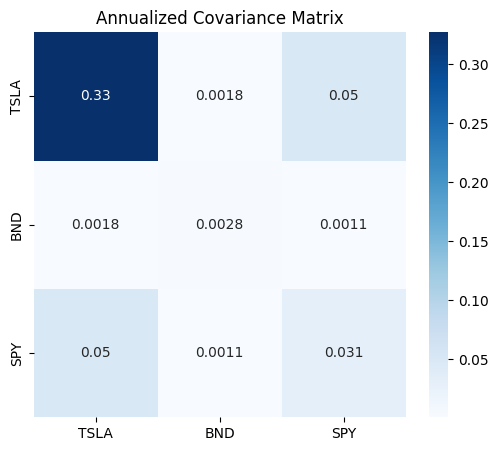

In [7]:
plt.figure(figsize=(6,5))

sns.heatmap(

    cov_matrix,

    annot=True,

    cmap="Blues"

)

plt.title("Annualized Covariance Matrix")

plt.show()

## Step 6. Maximum Sharpe Portfolio

In [8]:
ef = EfficientFrontier(

    expected_returns,

    cov_matrix
)

weights = ef.max_sharpe()

clean_weights = ef.clean_weights()

performance = ef.portfolio_performance(verbose=True)

Expected annual return: 7.6%
Annual volatility: 8.8%
Sharpe Ratio: 0.87


In [9]:
print(clean_weights)

OrderedDict({'TSLA': 0.0, 'BND': 0.54674, 'SPY': 0.45326})


## Step 7. Minimum Volatility Portfolio

In [10]:
ef_min = EfficientFrontier(

    expected_returns,

    cov_matrix
)

weights_min = ef_min.min_volatility()

clean_weights_min = ef_min.clean_weights()

performance_min = ef_min.portfolio_performance(verbose=True)

Expected annual return: 2.7%
Annual volatility: 5.2%
Sharpe Ratio: 0.51


## Step 8. Efficient Frontier Plot

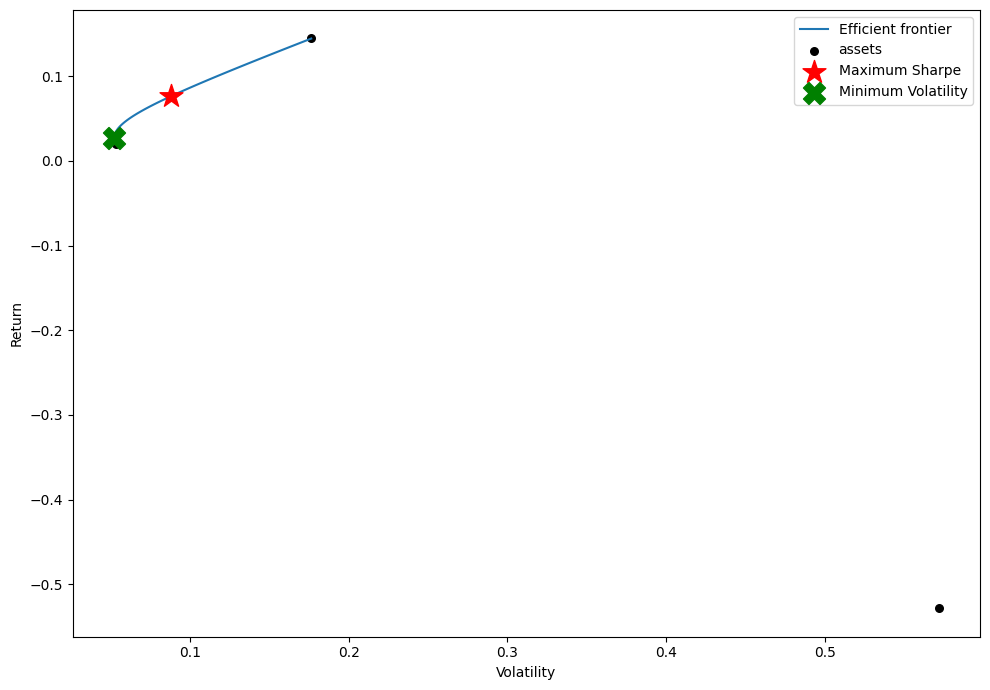

In [11]:
# Brand new object ONLY for drawing the frontier
ef_plot = EfficientFrontier(
    expected_returns,
    cov_matrix
)

fig, ax = plt.subplots(figsize=(10,7))

plotting.plot_efficient_frontier(
    ef_plot,
    ax=ax,
    show_assets=True
)

# Brand new object for Maximum Sharpe
ef_sharpe = EfficientFrontier(
    expected_returns,
    cov_matrix
)

ef_sharpe.max_sharpe(risk_free_rate=0.0)

ret, vol, sharpe = ef_sharpe.portfolio_performance(
    risk_free_rate=0.0
)

ax.scatter(
    vol,
    ret,
    marker="*",
    color="red",
    s=300,
    label="Maximum Sharpe",
    zorder=5
)

# Brand new object for Minimum Volatility
ef_min = EfficientFrontier(
    expected_returns,
    cov_matrix
)

ef_min.min_volatility()

ret2, vol2, sharpe2 = ef_min.portfolio_performance()

ax.scatter(
    vol2,
    ret2,
    marker="X",
    color="green",
    s=250,
    label="Minimum Volatility",
    zorder=5
)

ax.legend()

plt.show()

## Step 9. Portfolio Recommendation

In [12]:
recommendation = pd.DataFrame({

    "Asset": clean_weights.keys(),

    "Weight": clean_weights.values()

})

recommendation

,Asset,Weight
0,TSLA,0.00000
1,BND,0.54674
2,SPY,0.45326


## Step 10. Portfolio Metrics

In [13]:
ret, vol, sharpe = ef.portfolio_performance()

print(f"Expected Annual Return : {ret:.2%}")

print(f"Annual Volatility      : {vol:.2%}")

print(f"Sharpe Ratio           : {sharpe:.2f}")

Expected Annual Return : 7.63%
Annual Volatility      : 8.82%
Sharpe Ratio           : 0.87


## Step 11. Save Recommendation

In [14]:
recommendation.to_csv(

    "../data/processed/Optimal_Portfolio.csv",

    index=False
)